In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(0)

In [2]:
boston = fetch_openml(name='boston', version=1, as_frame=True)
df = boston.data.copy()
df['MEDV'] = boston.target.astype(float)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
X = df[['RM', 'LSTAT']].values
y = df['MEDV'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [4]:
sx = StandardScaler()
sy = StandardScaler()

X_train_n = sx.fit_transform(X_train)
X_test_n = sx.transform(X_test)
y_train_n = sy.fit_transform(y_train)

In [5]:
class Perceptron:
    def __init__(self, lr=0.05, epochs=500):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        n, m = X.shape
        self.w = np.zeros((m, 1))
        self.b = 0.0
        self.losses = []

        for i in range(self.epochs):
            y_pred = X @ self.w + self.b
            error = y_pred - y

            dw = (2 / n) * X.T @ error
            db = (2 / n) * np.sum(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            self.losses.append(np.mean(error ** 2))

    def predict(self, X):
        return X @ self.w + self.b

In [6]:
model = Perceptron(lr=0.05, epochs=500)
model.fit(X_train_n, y_train_n)

y_pred_n = model.predict(X_test_n)
y_pred = sy.inverse_transform(y_pred_n)

print('MSE:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

MSE: 37.3831056380951
R2: 0.5409084827270523


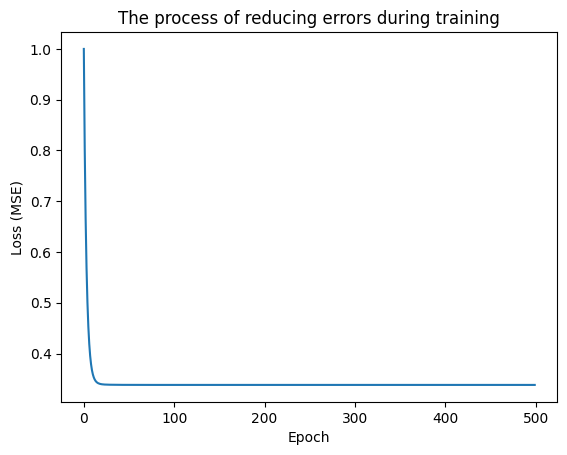

In [7]:
plt.plot(model.losses)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('The process of reducing errors during training')
plt.show()

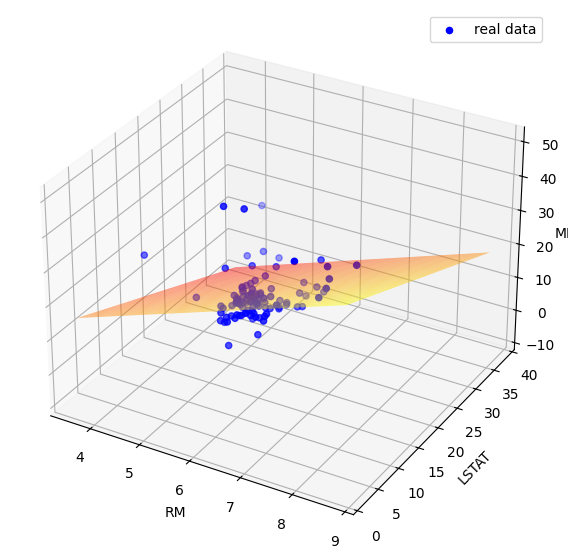

In [9]:
rm_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
lstat_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
RM, LSTAT = np.meshgrid(rm_range, lstat_range)

grid = np.column_stack([RM.ravel(), LSTAT.ravel()])
grid_n = sx.transform(grid)
pred_n = model.predict(grid_n)
Y_PRED = sy.inverse_transform(pred_n).reshape(RM.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_test[:, 0], X_test[:, 1], y_test.ravel(), color='blue', label='real data')
ax.plot_surface(RM, LSTAT, Y_PRED, alpha=0.5, cmap='autumn')
ax.set_xlabel('RM')
ax.set_ylabel('LSTAT')
ax.set_zlabel('MEDV')
ax.legend()
plt.show()